In [1]:
import os
os.chdir('../')

2025-09-03 23:49:02.498624: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


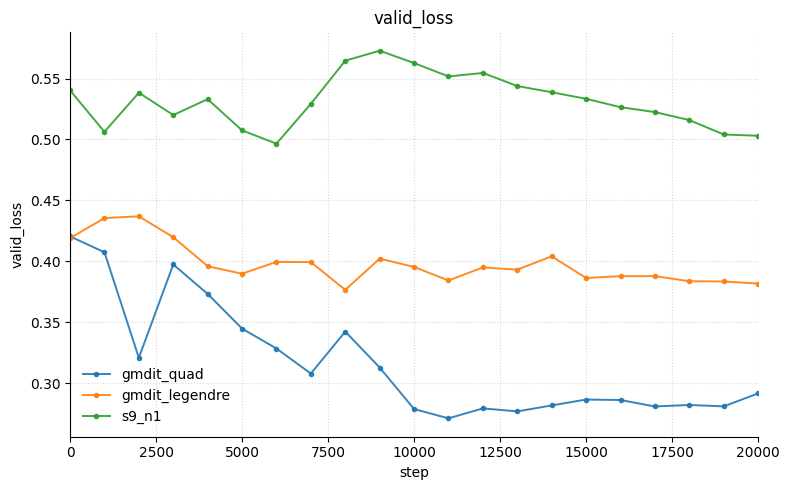

In [2]:
# TensorBoard scalars -> Matplotlib (explicit dirs, tags required; no UI, no error handling)
from tensorboard.backend.event_processing import event_accumulator as ea
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RUN_DIRS = ['logs/ablations/gmdit_quad/',
            'logs/ablations/gmdit_legendre/',
            'logs/gmdit/multi/s9_n1',
            ]
TAGS = ['valid_loss']

# load
metrics = {}  # {tag: {run: (steps, values)}}
for r in RUN_DIRS:
    acc = ea.EventAccumulator(r, size_guidance={ea.SCALARS:0}); acc.Reload()
    for t in acc.Tags()["scalars"]:
        ev = acc.Scalars(t)
        s = np.array([e.step for e in ev]); v = np.array([e.value for e in ev])
        i = np.argsort(s, kind="stable"); s, v = s[i], v[i]      # sort by step
        u, k = np.unique(s, return_index=True); s, v = u, v[k]   # dedup steps
        (metrics.setdefault(t, {}))[r] = (s, v)

if not TAGS:
    print("Available tags:"); 
    for t in sorted(metrics.keys()): print(" •", t)
else:
    for t in TAGS:
        if t not in metrics: continue
        fig, ax = plt.subplots(figsize=(8,5))
        for r,(s,v) in metrics[t].items():
            ax.plot(s, v, '-o', markersize=3, linewidth=1.4, alpha=0.9, label=Path(r).name)
        ax.set_title(t)
        ax.set_xlabel("step"); ax.set_ylabel(t.split("/")[-1])
        ax.grid(True, linestyle=":", alpha=0.5); ax.margins(x=0.02)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if len(metrics[t])>1: ax.legend(frameon=False)
        plt.xlim([0, 20*1000]); plt.tight_layout(); plt.show()


In [3]:
!nvidia-smi

Wed Sep  3 23:49:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.76.05              Driver Version: 580.76.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        Off |   00000000:19:00.0 Off |                  N/A |
| 31%   61C    P8             17W /  400W |      41MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----